Import

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path().resolve().parent
DATA_PATH = PROJECT_ROOT / "outputs" / "model_ready_dataset.csv"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
display(df.shape)
display(df.head())
display(df.info())

(2650, 25)

,subject_id,epoch_id,start_time_sec,eeg_channel,mean,std,min,max,signal_energy,log_signal_energy,...,relative_delta_power,relative_theta_power,relative_alpha_power,relative_beta_power,delta_theta_ratio,alpha_beta_ratio,sleep_stage,sleep_stage_encoded,id,sleep_stage_raw
0,0,0,0.0,EEG Fpz-Cz,0.398386,1.507148,-1.141560,2.346699,1.660815,1.660815,...,1.080622,3.459226,0.153448,-0.281266,1.047860,0.227384,Wake,0,2651,Sleep stage W
1,0,1,30.0,EEG Fpz-Cz,-1.542667,0.177387,-0.412640,0.652471,0.023789,0.023790,...,0.021183,0.453235,1.787639,2.270840,0.000191,1.702094,Wake,0,2652,Sleep stage W
2,0,2,60.0,EEG Fpz-Cz,1.955623,0.830146,-0.872690,0.442869,0.760013,0.760013,...,0.478585,-0.873316,1.779113,0.517644,0.446059,1.733541,Wake,0,2653,Sleep stage W
3,0,3,90.0,EEG Fpz-Cz,-1.385403,-0.922266,1.336357,-1.367269,-0.919471,-0.919472,...,-0.829650,-0.969059,1.797791,-0.616469,-0.810584,1.612606,Wake,0,2654,Sleep stage W
4,0,4,120.0,EEG Fpz-Cz,-0.639909,-0.888989,0.281786,-0.508906,-0.896766,-0.896767,...,-0.844126,0.319905,1.212340,-0.744325,-0.824235,1.070342,Wake,0,2655,Sleep stage W


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2650 entries, 0 to 2649
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   subject_id            2650 non-null   int64  
 1   epoch_id              2650 non-null   int64  
 2   start_time_sec        2650 non-null   float64
 3   eeg_channel           2650 non-null   object 
 4   mean                  2650 non-null   float64
 5   std                   2650 non-null   float64
 6   min                   2650 non-null   float64
 7   max                   2650 non-null   float64
 8   signal_energy         2650 non-null   float64
 9   log_signal_energy     2650 non-null   float64
 10  delta_power           2650 non-null   float64
 11  theta_power           2650 non-null   float64
 12  alpha_power           2650 non-null   float64
 13  beta_power            2650 non-null   float64
 14  total_power           2650 non-null   float64
 15  relative_delta_power 

None

Class Imbalance

C:\Users\Surface 4\AppData\Local\Temp\ipykernel_14940\3160700333.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


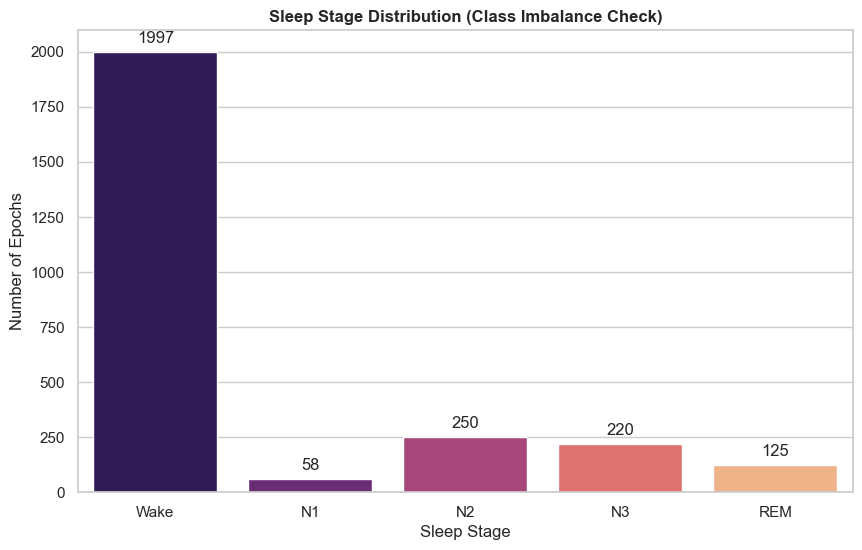

In [6]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df, 
    x='sleep_stage', 
    order=['Wake', 'N1', 'N2', 'N3', 'REM'], 
    palette='magma'
)
plt.title('Sleep Stage Distribution (Class Imbalance Check)', fontweight='bold')
plt.xlabel('Sleep Stage')
plt.ylabel('Number of Epochs')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.savefig(FIGURES_DIR / 'stage_distribution.png', bbox_inches='tight')
plt.show()

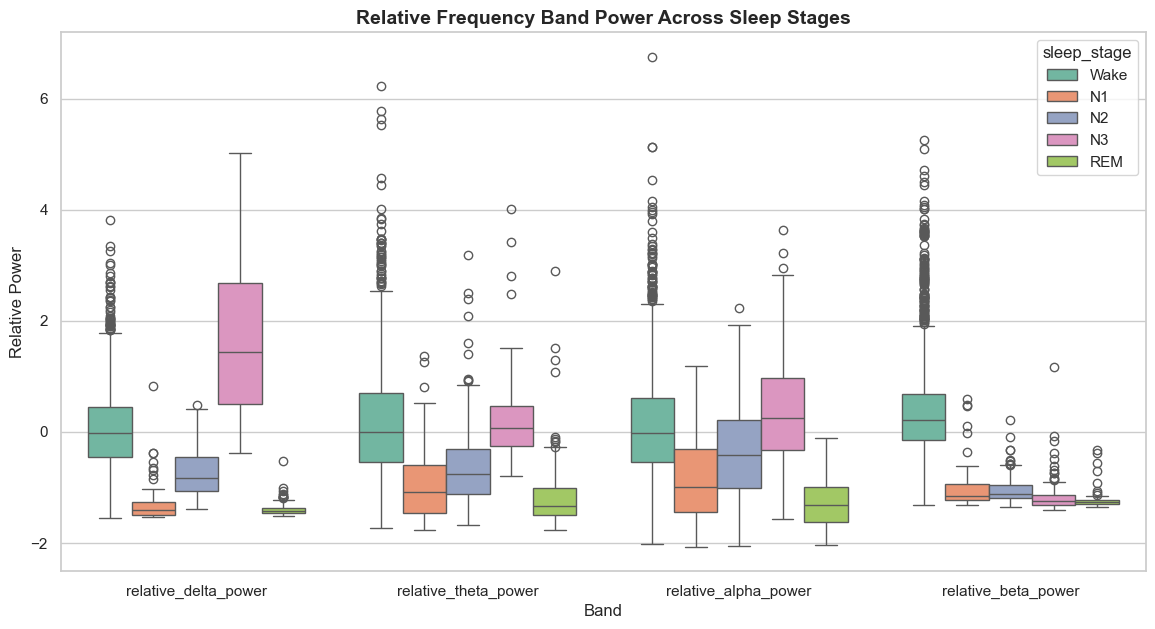

In [7]:
power_cols = ['relative_delta_power', 'relative_theta_power', 'relative_alpha_power', 'relative_beta_power']
df_melted = df.melt(id_vars=['sleep_stage'], value_vars=power_cols, var_name='Band', value_name='Relative Power')

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_melted, 
    x='Band', 
    y='Relative Power', 
    hue='sleep_stage', 
    palette='Set2'
)
plt.title('Relative Frequency Band Power Across Sleep Stages', fontsize=14, fontweight='bold')
plt.savefig(FIGURES_DIR / 'band_power_by_stage.png', bbox_inches='tight')
plt.show()

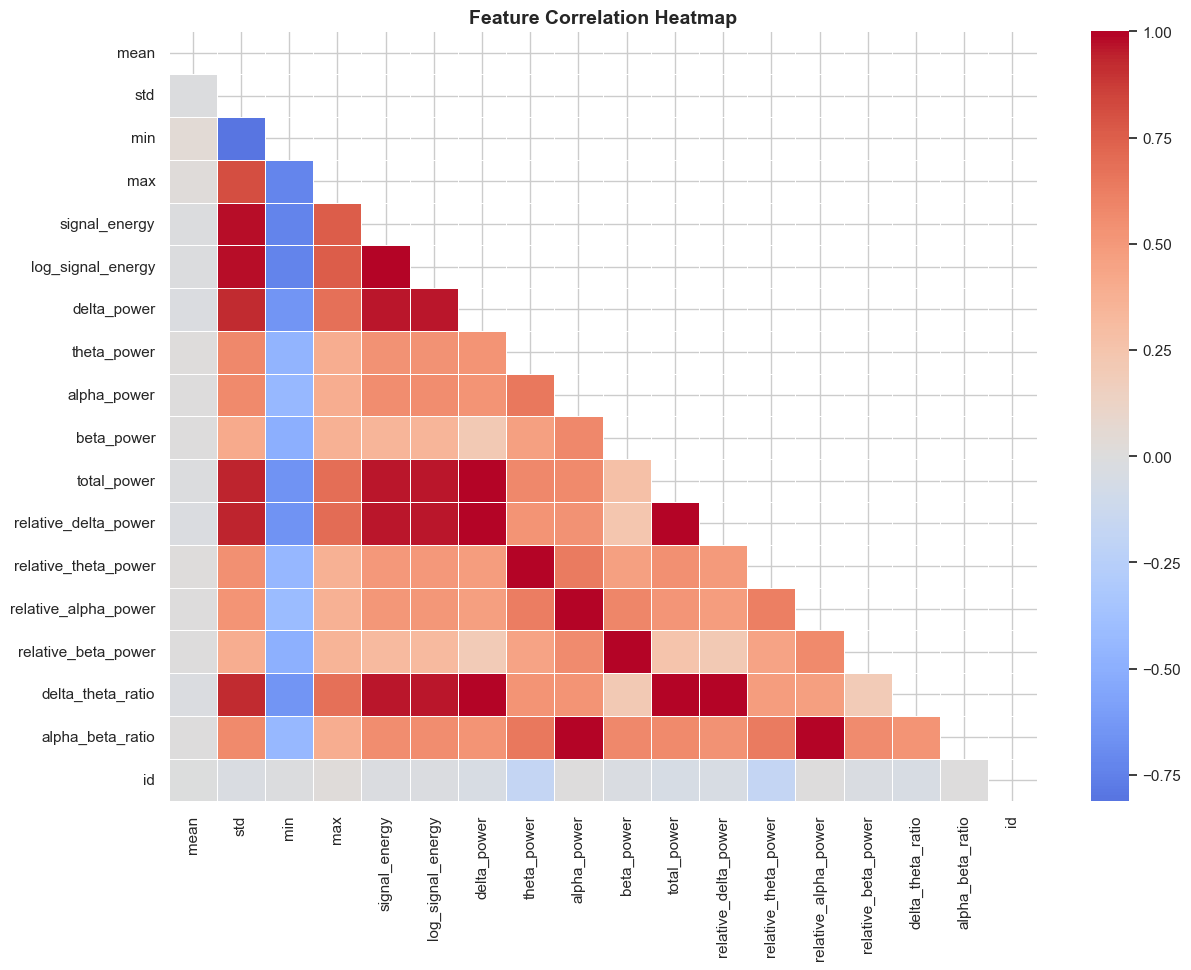

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
cols_to_drop = ['subject_id', 'epoch_id', 'start_time_sec', 'sleep_stage_encoded']
features_df = df[numeric_cols].drop(columns=[c for c in cols_to_drop if c in numeric_cols])

plt.figure(figsize=(14, 10))
corr = features_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    annot=False, 
    linewidths=0.5
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.savefig(FIGURES_DIR / 'feature_correlation.png', bbox_inches='tight')
plt.show()

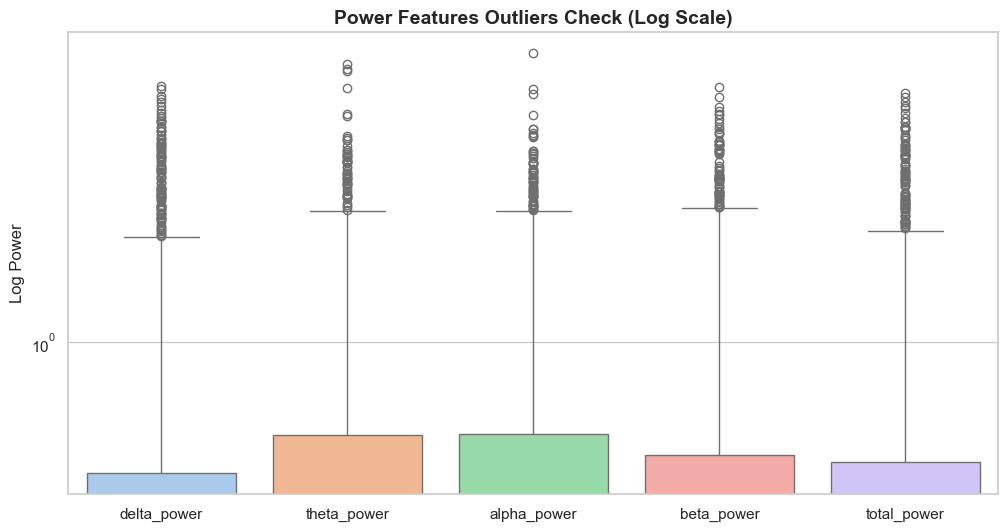

In [9]:
raw_power_cols = ['delta_power', 'theta_power', 'alpha_power', 'beta_power', 'total_power']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[raw_power_cols], palette='pastel')
plt.yscale('log')
plt.title('Power Features Outliers Check (Log Scale)', fontsize=14, fontweight='bold')
plt.ylabel('Log Power')
plt.savefig(FIGURES_DIR / 'power_outliers.png', bbox_inches='tight')
plt.show()